# Part A — Inverse Problem: Diffusion–Reaction (PINN)

**Governing PDE**

$$u_t = D\,u_{xx} - k\,u, \qquad x \in [0,1],\; t \in [0,1]$$

- $D = 0.001$ is **known**.
- $k$ is **unknown** and is the parameter we want to recover from data. True value: $k = 0.01$.
- Boundary conditions: $u(0,t) = u(1,t) = 0$.
- Initial condition: $u(x,0) = \sin(\pi x)$.



In [1]:
import numpy as np
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd

torch.manual_seed(0)
np.random.seed(0)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Known / true physical parameters
D = 0.001
k_true = 0.01


Using device: cuda


## 1. Ground-truth data generation

We discretize $x \in [0,1]$ into a grid, approximate $u_{xx}$ with a second-order
central difference (method of lines), and integrate the resulting ODE system in
time with `solve_ivp`. Dirichlet BCs $u(0,t)=u(1,t)=0$ are enforced by only
evolving the interior nodes.

Because the IC/BC choice above admits a closed-form solution
$u(x,t) = e^{-(D\pi^2 + k)t}\sin(\pi x)$, we also use it as a sanity check on the
numerical solver.


In [2]:
Nx = 101
x_grid = np.linspace(0, 1, Nx)
dx = x_grid[1] - x_grid[0]
x_int = x_grid[1:-1]  # interior nodes (BCs fix the endpoints at 0)

def diffusion_reaction_rhs(t, u_int, D, k):
    '''Right-hand side of du/dt for the interior nodes (Dirichlet BCs = 0).'''
    u_full = np.zeros(Nx)
    u_full[1:-1] = u_int
    u_xx = (u_full[2:] - 2 * u_full[1:-1] + u_full[:-2]) / dx**2
    return D * u_xx - k * u_full[1:-1]

u0 = np.sin(np.pi * x_int)          # initial condition on interior nodes
Nt = 101
t_grid = np.linspace(0, 1, Nt)

sol = solve_ivp(
    diffusion_reaction_rhs, (0, 1), u0, t_eval=t_grid,
    args=(D, k_true), method='RK45', rtol=1e-8, atol=1e-10,
)

U_true = np.zeros((Nt, Nx))          # rows = time, cols = space
U_true[:, 1:-1] = sol.y.T

# Sanity check against the closed-form analytic solution
X, T = np.meshgrid(x_grid, t_grid)
U_analytic = np.exp(-(D * np.pi**2 + k_true) * T) * np.sin(np.pi * X)
max_err = np.abs(U_true - U_analytic).max()
print(f"Max abs. error between FD/solve_ivp solution and analytic solution: {max_err:.3e}")


Max abs. error between FD/solve_ivp solution and analytic solution: 7.968e-07


### Visualize the ground-truth field

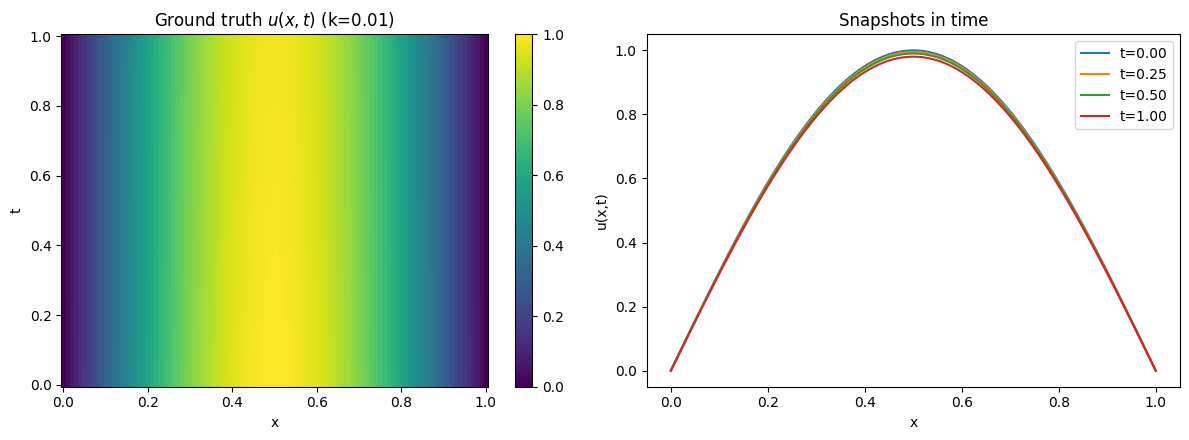

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

im = axes[0].pcolormesh(X, T, U_true, shading='auto', cmap='viridis')
axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
axes[0].set_title('Ground truth $u(x,t)$ (k=0.01)')
fig.colorbar(im, ax=axes[0])

for frac in [0.0, 0.25, 0.5, 1.0]:
    ti = int(frac * (Nt - 1))
    axes[1].plot(x_grid, U_true[ti], label=f't={t_grid[ti]:.2f}')
axes[1].set_xlabel('x'); axes[1].set_ylabel('u(x,t)')
axes[1].set_title('Snapshots in time')
axes[1].legend()

plt.tight_layout()
plt.show()


## 2. Sample observations

We draw 100 random $(x,t)$ points from the ground-truth grid to act as sparse
sensor measurements. A helper function injects Gaussian noise scaled to the
standard deviation of the observed values, at whatever $\sigma$ we ask for.


In [4]:
N_OBS = 100
obs_rng = np.random.default_rng(42)  # fixed RNG -> same sensor locations for every noise level

idx_t = obs_rng.integers(0, Nt, N_OBS)
idx_x = obs_rng.integers(0, Nx, N_OBS)

x_obs = x_grid[idx_x]
t_obs = t_grid[idx_t]
u_obs_clean = U_true[idx_t, idx_x]

def add_noise(u_clean, sigma, seed=123):
    '''Add Gaussian noise with std = sigma * std(u_clean).'''
    if sigma == 0:
        return u_clean.copy()
    rng = np.random.default_rng(seed)
    return u_clean + sigma * np.std(u_clean) * rng.standard_normal(u_clean.shape)

print(f"Sampled {N_OBS} observation points.")
print(f"u_obs range: [{u_obs_clean.min():.4f}, {u_obs_clean.max():.4f}], std: {np.std(u_obs_clean):.4f}")


Sampled 100 observation points.
u_obs range: [0.0000, 0.9968], std: 0.3065


## 3. PINN model

A standard fully-connected `tanh` network maps $(x,t) \mapsto u$. The unknown
$k$ is a scalar `nn.Parameter` trained jointly with the network, following the
inverse-problem pattern as per the assignment.

We give $k$ its own (larger) learning rate in a separate Adam parameter group,
since a single scalar otherwise moves much more slowly than the network
weights under a shared learning rate.


In [5]:
class PINN(nn.Module):
    def __init__(self, layers=(2, 40, 40, 40, 1)):
        super().__init__()
        modules = []
        for i in range(len(layers) - 2):
            modules.append(nn.Linear(layers[i], layers[i + 1]))
            modules.append(nn.Tanh())
        modules.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*modules)

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


def pde_residual(model, x, t, D, k):
    '''Compute u_t - D*u_xx + k*u at collocation points (x, t), via autograd.'''
    u = model(x, t)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    return u_t - D * u_xx + k * u


## 4. Training loop with noise sweep


In [6]:
def train_inverse_problem(sigma, epochs=6000, k_init=0.02, seed=0,
                           n_collocation=2000, n_ic=100, n_bc=100,
                           data_weight=5.0, verbose=False):
    torch.manual_seed(seed)

    u_obs_noisy = add_noise(u_obs_clean, sigma)
    x_obs_t = torch.tensor(x_obs, dtype=torch.float32).view(-1, 1)
    t_obs_t = torch.tensor(t_obs, dtype=torch.float32).view(-1, 1)
    u_obs_t = torch.tensor(u_obs_noisy, dtype=torch.float32).view(-1, 1)

    model = PINN()
    k_param = torch.nn.Parameter(torch.tensor([k_init]))

    # Collocation points for the PDE residual, sampled once over the domain
    x_c = torch.rand(n_collocation, 1, requires_grad=True)
    t_c = torch.rand(n_collocation, 1, requires_grad=True)

    # Initial-condition points: u(x, 0) = sin(pi x)
    x_ic = torch.rand(n_ic, 1)
    t_ic = torch.zeros(n_ic, 1)
    u_ic = torch.sin(np.pi * x_ic)

    # Boundary-condition points: u(0, t) = u(1, t) = 0
    t_bc = torch.rand(n_bc, 1)
    x_bc0 = torch.zeros(n_bc, 1)
    x_bc1 = torch.ones(n_bc, 1)

    optimizer = torch.optim.Adam([
        {'params': model.parameters(), 'lr': 1e-3},
        {'params': [k_param], 'lr': 5e-3},   # k needs a larger LR to keep pace with the network
    ])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3000, gamma=0.5)

    k_history, loss_history = [], []

    for epoch in range(epochs):
        optimizer.zero_grad()

        res = pde_residual(model, x_c, t_c, D, k_param)
        L_pde = (res ** 2).mean()
        L_ic = ((model(x_ic, t_ic) - u_ic) ** 2).mean()
        L_bc = (model(x_bc0, t_bc) ** 2).mean() + (model(x_bc1, t_bc) ** 2).mean()
        L_data = ((model(x_obs_t, t_obs_t) - u_obs_t) ** 2).mean()

        loss = L_pde + L_ic + L_bc + data_weight * L_data
        loss.backward()
        optimizer.step()
        scheduler.step()

        k_history.append(k_param.item())
        loss_history.append(loss.item())

        if verbose and epoch % 1500 == 0:
            print(f"  epoch {epoch:5d} | loss {loss.item():.3e} | "
                  f"pde {L_pde.item():.2e} ic {L_ic.item():.2e} "
                  f"bc {L_bc.item():.2e} data {L_data.item():.2e} | k={k_param.item():.5f}")

    return {
        'model': model,
        'k_recovered': k_param.item(),
        'k_history': k_history,
        'loss_history': loss_history,
        'sigma': sigma,
    }


In [7]:
noise_levels = [0.0, 0.01, 0.05]
results = {}

for sigma in noise_levels:
    print(f"Training PINN for noise level sigma = {sigma*100:.0f}% ...")
    results[sigma] = train_inverse_problem(sigma, epochs=6000, verbose=True)
    print(f"  -> recovered k = {results[sigma]['k_recovered']:.6f}\n")


Training PINN for noise level sigma = 0% ...
  epoch     0 | loss 3.416e+00 | pde 9.70e-04 ic 5.65e-01 bc 3.32e-03 data 5.69e-01 | k=0.02500
  epoch  1500 | loss 8.322e-05 | pde 4.45e-05 ic 4.65e-06 bc 7.83e-06 data 5.24e-06 | k=0.01102
  epoch  3000 | loss 4.360e-05 | pde 1.42e-05 ic 3.16e-06 bc 1.03e-05 data 3.18e-06 | k=0.01029
  epoch  4500 | loss 1.508e-05 | pde 8.96e-06 ic 1.05e-06 bc 1.18e-06 data 7.80e-07 | k=0.01030
  -> recovered k = 0.010278

Training PINN for noise level sigma = 1% ...
  epoch     0 | loss 3.417e+00 | pde 9.70e-04 ic 5.65e-01 bc 3.32e-03 data 5.69e-01 | k=0.02500
  epoch  1500 | loss 1.104e-04 | pde 4.34e-05 ic 5.05e-06 bc 7.89e-06 data 1.08e-05 | k=0.01042
  epoch  3000 | loss 5.859e-05 | pde 1.51e-05 ic 2.41e-06 bc 2.39e-06 data 7.73e-06 | k=0.00971
  epoch  4500 | loss 4.754e-05 | pde 9.89e-06 ic 1.27e-06 bc 1.27e-06 data 7.02e-06 | k=0.00965
  -> recovered k = 0.009606

Training PINN for noise level sigma = 5% ...
  epoch     0 | loss 3.421e+00 | pde 9.

## 5. Deliverable 1 — Recovered $k$ vs. noise level

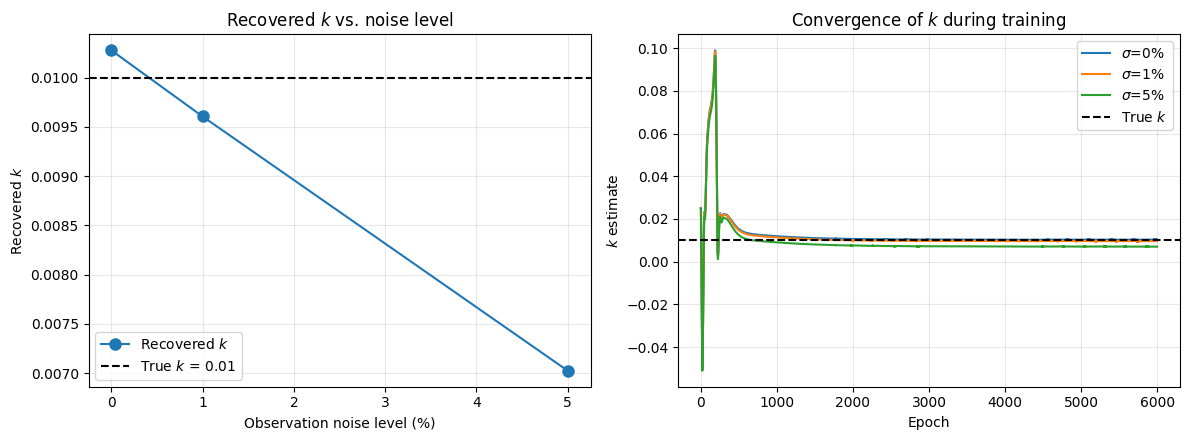

In [8]:
sigmas_pct = [s * 100 for s in noise_levels]
k_recovered = [results[s]['k_recovered'] for s in noise_levels]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(sigmas_pct, k_recovered, 'o-', color='C0', markersize=8, label='Recovered $k$')
axes[0].axhline(k_true, linestyle='--', color='k', label=f'True $k$ = {k_true}')
axes[0].set_xlabel('Observation noise level (%)')
axes[0].set_ylabel('Recovered $k$')
axes[0].set_title('Recovered $k$ vs. noise level')
axes[0].legend()
axes[0].grid(alpha=0.3)

for sigma in noise_levels:
    axes[1].plot(results[sigma]['k_history'], label=f'$\\sigma$={sigma*100:.0f}%')
axes[1].axhline(k_true, linestyle='--', color='k', label='True $k$')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('$k$ estimate')
axes[1].set_title('Convergence of $k$ during training')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Deliverable 2 — Summary table

In [9]:
rows = []
for sigma in noise_levels:
    k_rec = results[sigma]['k_recovered']
    rel_err = abs(k_rec - k_true) / k_true * 100
    rows.append({
        'Noise level': f'{sigma*100:.0f}%',
        'Recovered k': f'{k_rec:.6f}',
        'True k': k_true,
        'Relative error (%)': f'{rel_err:.2f}',
    })

summary_df = pd.DataFrame(rows)
summary_df


,Noise level,Recovered k,True k,Relative error (%)
0,0%,0.010278,0.01,2.78
1,1%,0.009606,0.01,3.94
2,5%,0.007024,0.01,29.76


## 7. Sanity check — PINN field vs. ground truth (noiseless case)

As a final check, we compare the trained PINN's predicted field to the ground
truth for the $\sigma = 0\%$ run.


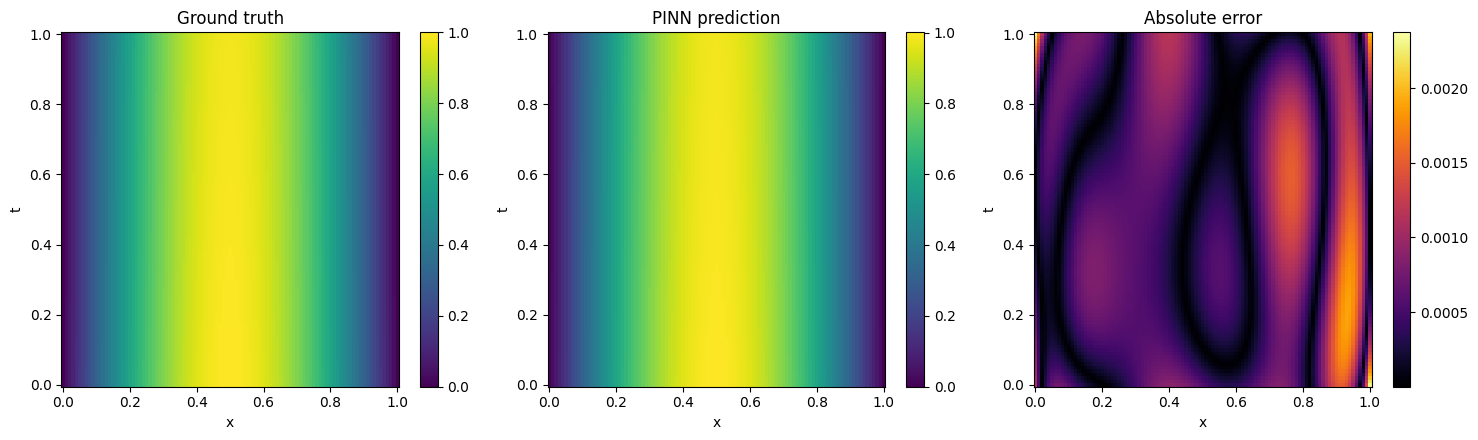

Recovered k (0% noise): 0.010278  (true k = 0.01)


In [10]:
model0 = results[0.0]['model']
model0.eval()

x_flat = torch.tensor(X.flatten(), dtype=torch.float32).view(-1, 1)
t_flat = torch.tensor(T.flatten(), dtype=torch.float32).view(-1, 1)
with torch.no_grad():
    U_pred = model0(x_flat, t_flat).numpy().reshape(X.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

im0 = axes[0].pcolormesh(X, T, U_true, shading='auto', cmap='viridis')
axes[0].set_title('Ground truth'); axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(X, T, U_pred, shading='auto', cmap='viridis')
axes[1].set_title('PINN prediction'); axes[1].set_xlabel('x'); axes[1].set_ylabel('t')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(X, T, np.abs(U_true - U_pred), shading='auto', cmap='inferno')
axes[2].set_title('Absolute error'); axes[2].set_xlabel('x'); axes[2].set_ylabel('t')
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Recovered k (0% noise): {results[0.0]['k_recovered']:.6f}  (true k = {k_true})")


## Observation

Recovery accuracy degrades monotonically as observation noise increases,
  which is the expected behavior for a data-driven inverse problem: the
  L_data term is the only source of information about $k$, so noisier
  observations give a noisier gradient signal for the scalar parameter.
